# NeuroScope AI - Notebook 09: Ensemble & Consensus

Ties all 6 cancer pipelines together into the verification gate system.

**What this notebook builds:**
1. ONNX inference wrappers for all 6 pipeline models
2. Detection Ensemble (Agent 2) -- EfficientNet-B4 + ResNet-152 + ViT-B/16
3. Verification Gate (Agent 2.5) -- cancer-specific thresholds before accepting 'normal'
4. Segmentation consensus -- STAPLE algorithm for mask fusion
5. Classification consensus -- majority vote + confidence scoring
6. End-to-end pipeline test on one sample per cancer type

**Verification gate thresholds (from project plan):**
- Brain    : 97% -- all 3 models must agree above this to call normal
- Melanoma : 99% -- highest threshold, most dangerous miss
- Breast   : 95%
- Lung     : 95%
- Liver    : 93%
- Spine    : 93%

**Design principle:**
False negatives (missing cancer) are catastrophically worse than false positives.
The gate is biased heavily toward detection -- 'normal' requires unanimous high-confidence
agreement from all 3 architectures PLUS a mini-segmentation second check.

NOTE: This notebook uses the ONNX models produced by each pipeline notebook.
Run ONNX export cells in NB03-NB08B before running Cell 4+ here.

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn.functional as F
import cv2
import onnxruntime as ort

BASE    = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS      = os.path.join(BASE, 'datasets')
MODELS  = os.path.join(BASE, 'models', 'production')
OUT     = os.path.join(BASE, 'outputs', 'nb09_ensemble')
os.makedirs(OUT, exist_ok=True)
sys.path.insert(0, BASE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'ONNX RT : {ort.__version__}')

# ONNX providers -- GPU first, CPU fallback
PROVIDERS = (
    ['CUDAExecutionProvider', 'CPUExecutionProvider']
    if torch.cuda.is_available()
    else ['CPUExecutionProvider']
)
print(f'Providers: {PROVIDERS}')
print('Imports OK')

Device  : cuda
ONNX RT : 1.26.0
Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
Imports OK


---
## Cell 2 - Verification Gate Config

In [19]:
import os

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS = os.path.join(BASE, 'models', 'production')

NORMAL_THRESHOLDS = {
    'brain'   : 0.97,
    'melanoma': 0.99,
    'breast'  : 0.95,
    'lung'    : 0.95,
    'liver'   : 0.93,
    'spine'   : 0.93,
    'skin'    : 0.97,
}

ONNX_PATHS = {
    'brain_cls'  : os.path.join(MODELS, 'brain_cls',  'brain_cls_efficientnet.onnx'),
    'brain_seg'  : os.path.join(MODELS, 'brain_seg',  'brain_seg_resnet.onnx'),
    'breast_det' : os.path.join(MODELS, 'breast_det', 'breast_det_efficientnet.onnx'),
    'liver_seg'  : os.path.join(MODELS, 'liver_seg',  'liver_seg_resnet.onnx'),
    'lung_det'   : os.path.join(MODELS, 'lung_det',   'lung_det_resnet3d.onnx'),
    'skin_cls'   : os.path.join(MODELS, 'skin_cls',   'skin_cls_efficientnet.onnx'),
    'spine_cls'  : os.path.join(MODELS, 'spine',      'spine_hybridspinenet.onnx'),
}

PIPELINES = {
    'brain' : {
        'modality'  : '3D MRI (T1/T1ce/T2/FLAIR)',
        'task'      : 'segmentation + classification',
        'threshold' : NORMAL_THRESHOLDS['brain'],
        'models'    : ['brain_seg', 'brain_cls'],
        'classes'   : ['no_tumor', 'glioma', 'meningioma', 'pituitary'],
    },
    'lung'  : {
        'modality'  : 'Low-dose CT',
        'task'      : 'nodule detection',
        'threshold' : NORMAL_THRESHOLDS['lung'],
        'models'    : ['lung_det'],
        'classes'   : ['no_nodule', 'nodule'],
    },
    'breast': {
        'modality'  : 'Mammography',
        'task'      : 'binary classification',
        'threshold' : NORMAL_THRESHOLDS['breast'],
        'models'    : ['breast_det'],
        'classes'   : ['benign', 'malignant'],
    },
    'liver' : {
        'modality'  : 'Contrast CT',
        'task'      : 'segmentation',
        'threshold' : NORMAL_THRESHOLDS['liver'],
        'models'    : ['liver_seg'],
        'classes'   : ['background', 'liver', 'tumor'],
    },
    'skin'  : {
        'modality'  : 'Dermoscopy',
        'task'      : '7-class classification',
        'threshold' : NORMAL_THRESHOLDS['skin'],
        'models'    : ['skin_cls'],
        'classes'   : ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc'],
    },
    'spine' : {
        'modality'  : 'Lumbar MRI (3 views)',
        'task'      : '25-target severity grading',
        'threshold' : NORMAL_THRESHOLDS['spine'],
        'models'    : ['spine_cls'],
        'classes'   : ['Normal/Mild', 'Moderate', 'Severe'],
    },
}

print('Verification gate thresholds:')
for cancer, thresh in NORMAL_THRESHOLDS.items():
    print(f'  {cancer:10s}: {thresh*100:.0f}%')

print('\nONNX model status:')
for name, path in ONNX_PATHS.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / (1024**2) if exists else 0
    status = f'OK ({size:.1f} MB)' if exists else 'MISSING'
    print(f'  {name:15s}: {status}')

Verification gate thresholds:
  brain     : 97%
  melanoma  : 99%
  breast    : 95%
  lung      : 95%
  liver     : 93%
  spine     : 93%
  skin      : 97%

ONNX model status:
  brain_cls      : OK (72.0 MB)
  brain_seg      : OK (18.0 MB)
  breast_det     : OK (70.7 MB)
  liver_seg      : OK (24.1 MB)
  lung_det       : OK (27.3 MB)
  skin_cls       : OK (71.0 MB)
  spine_cls      : OK (273.2 MB)


---
## Cell 3 - ONNX Inference Wrappers

In [20]:
import os, numpy as np, cv2
import onnxruntime as ort

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS    = os.path.join(BASE, 'models', 'production')
PROVIDERS = ['CUDAExecutionProvider', 'CPUExecutionProvider']

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_session(onnx_path):
    if not os.path.exists(onnx_path):
        return None
    try:
        return ort.InferenceSession(onnx_path, providers=PROVIDERS)
    except Exception as e:
        print(f'  Failed to load {os.path.basename(onnx_path)}: {e}')
        return None


def get_input_size(sess):
    shape = sess.get_inputs()[0].shape
    try:
        return int(shape[2])
    except Exception:
        return 256


def preprocess_2d(img_bgr, img_size=256):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    img = img.transpose(2, 0, 1)
    return np.expand_dims(img, axis=0)


def preprocess_mammogram(img_bgr, img_size=512):
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    img   = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    img   = cv2.resize(img, (img_size, img_size))
    img   = img.astype(np.float32) / 255.0
    img   = (img - IMAGENET_MEAN) / IMAGENET_STD
    img   = img.transpose(2, 0, 1)
    return np.expand_dims(img, axis=0)


def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def softmax_3d(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class BrainClassifier:
    def __init__(self, onnx_path):
        self.sess    = load_session(onnx_path)
        self.classes = ['no_tumor', 'glioma', 'meningioma', 'pituitary']
        self.size    = get_input_size(self.sess) if self.sess else 224

    def predict(self, img_bgr):
        if self.sess is None:
            return None
        x      = preprocess_2d(img_bgr, self.size)
        logits = self.sess.run(None, {'input': x})[0]
        probs  = softmax(logits[0])
        return {'probs': probs, 'class': self.classes[probs.argmax()],
                'confidence': float(probs.max())}


class BrainSegmentor:
    """
    3D SegResNet wrapper.
    Accepts a 2D slice for quick pipeline testing.
    Full 3D inference requires a 4-channel 3D volume [4, D, H, W].
    """
    def __init__(self, onnx_path):
        self.sess = load_session(onnx_path)

    def predict_2d_slice(self, img_bgr):
        """
        Quick test mode: convert 2D image to minimal 3D volume.
        Not for clinical use -- only for pipeline smoke testing.
        """
        if self.sess is None:
            return None
        try:
            gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            gray  = cv2.resize(gray, (128, 128)).astype(np.float32) / 255.0
            # 4 channels (T1/T1ce/T2/FLAIR), depth=128 -- replicate slice
            vol   = np.stack([gray] * 128, axis=0)        # [D, H, W]
            vol4  = np.stack([vol] * 4, axis=0)           # [4, D, H, W]
            inp   = vol4[np.newaxis].astype(np.float32)   # [1, 4, D, H, W]
            out   = self.sess.run(None, {'input': inp})[0]
            # out: [1, 4, D, H, W] -- check tumor channels
            tumor_prob = float(out[0, 1:].max())
            return {'tumor_prob': tumor_prob,
                    'class': 'tumor' if tumor_prob > 0.5 else 'no_tumor',
                    'confidence': tumor_prob if tumor_prob > 0.5 else 1 - tumor_prob}
        except Exception as e:
            return {'tumor_prob': 0.0, 'class': 'no_tumor',
                    'confidence': 0.0, 'error': str(e)}


class BreastDetector:
    def __init__(self, onnx_path):
        self.sess = load_session(onnx_path)
        self.size = get_input_size(self.sess) if self.sess else 512

    def predict(self, img_bgr):
        if self.sess is None:
            return None
        x      = preprocess_mammogram(img_bgr, self.size)
        logit  = self.sess.run(None, {'input': x})[0]
        prob_m = float(sigmoid(logit[0][0]))
        return {'prob_malignant': prob_m,
                'class': 'malignant' if prob_m > 0.5 else 'benign',
                'confidence': prob_m if prob_m > 0.5 else 1 - prob_m}


class LiverSegmentor:
    """
    3D SegResNet wrapper for liver segmentation.
    Quick test mode uses a synthetic 3D volume from a 2D CT slice.
    """
    def __init__(self, onnx_path):
        self.sess = load_session(onnx_path)

    def predict_2d_slice(self, img_bgr):
        if self.sess is None:
            return None
        try:
            gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            gray  = cv2.resize(gray, (128, 128)).astype(np.float32) / 255.0
            # HU windowing approximation on normalized image
            vol   = np.stack([gray] * 128, axis=0)       # [D, H, W]
            inp   = vol[np.newaxis, np.newaxis].astype(np.float32)  # [1,1,D,H,W]
            out   = self.sess.run(None, {'input': inp})[0]
            tumor_prob = float(sigmoid(out[0].max()))
            return {'tumor_prob': tumor_prob,
                    'class': 'tumor' if tumor_prob > 0.5 else 'normal',
                    'confidence': tumor_prob if tumor_prob > 0.5 else 1 - tumor_prob}
        except Exception as e:
            return {'tumor_prob': 0.0, 'class': 'normal',
                    'confidence': 0.0, 'error': str(e)}


class LungDetector:
    """
    3D CNN nodule detector wrapper.
    Accepts a 2D image for smoke testing -- converts to a 3D patch.
    """
    def __init__(self, onnx_path):
        self.sess = load_session(onnx_path)

    def predict_2d_slice(self, img_bgr):
        if self.sess is None:
            return None
        try:
            gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            gray  = cv2.resize(gray, (32, 32)).astype(np.float32) / 255.0
            patch = np.stack([gray] * 32, axis=0)         # [D, H, W]
            inp   = patch[np.newaxis, np.newaxis].astype(np.float32)  # [1,1,D,H,W]
            out   = self.sess.run(None, {'input': inp})[0]
            prob  = float(sigmoid(out[0][0]))
            return {'nodule_prob': prob,
                    'class': 'nodule' if prob > 0.5 else 'no_nodule',
                    'confidence': prob if prob > 0.5 else 1 - prob}
        except Exception as e:
            return {'nodule_prob': 0.0, 'class': 'no_nodule',
                    'confidence': 0.0, 'error': str(e)}


class SkinClassifier:
    def __init__(self, onnx_path):
        self.sess    = load_session(onnx_path)
        self.classes = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
        self.names   = {
            'mel': 'Melanoma', 'nv': 'Nevus', 'bcc': 'BCC',
            'akiec': 'Actinic K.', 'bkl': 'Ben. Kerat.',
            'df': 'Dermatofibroma', 'vasc': 'Vascular'
        }
        self.size    = get_input_size(self.sess) if self.sess else 384

    def predict(self, img_bgr):
        if self.sess is None:
            return None
        x      = preprocess_2d(img_bgr, self.size)
        logits = self.sess.run(None, {'input': x})[0]
        probs  = softmax(logits[0])
        cls    = self.classes[probs.argmax()]
        return {'probs': probs, 'class': cls,
                'name': self.names[cls],
                'confidence': float(probs.max()),
                'mel_prob': float(probs[0])}


class SpineClassifier:
    CONDITIONS = [
        'spinal_canal_stenosis',
        'left_neural_foraminal_narrowing',
        'right_neural_foraminal_narrowing',
        'left_subarticular_stenosis',
        'right_subarticular_stenosis',
    ]
    LEVELS   = ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']
    SEVERITY = ['Normal/Mild', 'Moderate', 'Severe']

    def __init__(self, onnx_path):
        self.sess    = load_session(onnx_path)
        self.targets = [f'{c}_{l}' for c in self.CONDITIONS for l in self.LEVELS]
        self.size    = get_input_size(self.sess) if self.sess else 384

    def predict(self, sag_t1_bgr, sag_t2_bgr, ax_t2_bgr):
        if self.sess is None:
            return None
        v1 = preprocess_2d(sag_t1_bgr, self.size)
        v2 = preprocess_2d(sag_t2_bgr, self.size)
        v3 = preprocess_2d(ax_t2_bgr,  self.size)
        logits, cauda = self.sess.run(
            None, {'sag_t1': v1, 'sag_t2': v2, 'ax_t2': v3}
        )
        probs   = softmax_3d(logits[0])
        preds   = probs.argmax(axis=1)
        cauda_p = float(sigmoid(cauda[0][0]))
        severe_targets = [self.targets[i] for i in range(25) if preds[i] == 2]
        return {
            'probs'         : probs,
            'preds'         : preds,
            'cauda_prob'    : cauda_p,
            'cauda_flag'    : cauda_p > 0.5,
            'severe_targets': severe_targets,
            'n_severe'      : int((preds == 2).sum()),
        }


# ── Load all models ───────────────────────────────────────────────────────────
ONNX_PATHS = {
    'brain_cls'  : os.path.join(MODELS, 'brain_cls',  'brain_cls_efficientnet.onnx'),
    'brain_seg'  : os.path.join(MODELS, 'brain_seg',  'brain_seg_resnet.onnx'),
    'breast_det' : os.path.join(MODELS, 'breast_det', 'breast_det_efficientnet.onnx'),
    'liver_seg'  : os.path.join(MODELS, 'liver_seg',  'liver_seg_resnet.onnx'),
    'lung_det'   : os.path.join(MODELS, 'lung_det',   'lung_det_resnet3d.onnx'),
    'skin_cls'   : os.path.join(MODELS, 'skin_cls',   'skin_cls_efficientnet.onnx'),
    'spine_cls'  : os.path.join(MODELS, 'spine',      'spine_hybridspinenet.onnx'),
}

brain_cls_model  = BrainClassifier(ONNX_PATHS['brain_cls'])
brain_seg_model  = BrainSegmentor(ONNX_PATHS['brain_seg'])
breast_model     = BreastDetector(ONNX_PATHS['breast_det'])
liver_model      = LiverSegmentor(ONNX_PATHS['liver_seg'])
lung_model       = LungDetector(ONNX_PATHS['lung_det'])
skin_model       = SkinClassifier(ONNX_PATHS['skin_cls'])
spine_model      = SpineClassifier(ONNX_PATHS['spine_cls'])

print('Model load status:')
for name, path in ONNX_PATHS.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / (1024**2) if exists else 0
    print(f'  {name:15s}: {"OK" if exists else "MISSING"} ({size:.1f} MB)')
print('Wrappers OK')

Model load status:
  brain_cls      : OK (72.0 MB)
  brain_seg      : OK (18.0 MB)
  breast_det     : OK (70.7 MB)
  liver_seg      : OK (24.1 MB)
  lung_det       : OK (27.3 MB)
  skin_cls       : OK (71.0 MB)
  spine_cls      : OK (273.2 MB)
Wrappers OK


---
## Cell 4 - Verification Gate (Agent 2.5)

In [21]:
import numpy as np
from dataclasses import dataclass, field
from typing import List, Dict, Optional

NORMAL_THRESHOLDS = {
    'brain'   : 0.97,
    'melanoma': 0.99,
    'breast'  : 0.95,
    'lung'    : 0.95,
    'liver'   : 0.93,
    'spine'   : 0.93,
    'skin'    : 0.97,
}


@dataclass
class ModelPrediction:
    model_name  : str
    cancer_prob : float          # probability of cancer/abnormality
    class_name  : str
    confidence  : float
    raw_probs   : np.ndarray
    metadata    : Dict = field(default_factory=dict)


@dataclass
class GateResult:
    cancer_type       : str
    verdict           : str      # 'CANCER_FLAGGED' | 'NORMAL' | 'REVIEW_REQUIRED'
    priority          : int      # 1=emergency, 2=urgent, 3=routine, 4=normal
    ensemble_prob     : float    # mean cancer probability across models
    model_agreement   : float    # fraction of models that agree on verdict
    threshold_used    : float
    predictions       : List[ModelPrediction]
    gate_passed       : bool     # True = confident normal
    flag_reason       : str = ''
    cauda_flag        : bool = False


class VerificationGate:
    """
    Agent 2.5 -- The Double-Check.

    Rules:
    1. Collect predictions from all available models for this cancer type.
    2. Compute ensemble probability (mean) and model agreement.
    3. If ANY model exceeds cancer threshold -> CANCER_FLAGGED.
    4. If ALL models agree normal AND all above threshold for normal -> NORMAL.
    5. Otherwise -> REVIEW_REQUIRED (human must decide).
    6. Cauda equina flag always overrides to Priority 1 emergency.
    """

    def __init__(self, thresholds=None):
        self.thresholds = thresholds or NORMAL_THRESHOLDS

    def run(self, cancer_type: str,
            predictions: List[ModelPrediction],
            cauda_flag: bool = False) -> GateResult:

        if not predictions:
            return GateResult(
                cancer_type=cancer_type, verdict='REVIEW_REQUIRED',
                priority=2, ensemble_prob=0.5, model_agreement=0.0,
                threshold_used=0.0, predictions=[], gate_passed=False,
                flag_reason='No model predictions available'
            )

        threshold = self.thresholds.get(cancer_type, 0.95)

        # Ensemble probability: mean cancer prob across all models
        cancer_probs  = [p.cancer_prob for p in predictions]
        ensemble_prob = float(np.mean(cancer_probs))

        # Model agreement: how many agree on same verdict
        cancer_votes  = sum(1 for p in cancer_probs if p > 0.5)
        normal_votes  = len(predictions) - cancer_votes
        agreement     = max(cancer_votes, normal_votes) / len(predictions)

        # Gate logic
        if cauda_flag:
            # Cauda equina = always Priority 1, always flagged
            verdict      = 'CANCER_FLAGGED'
            priority     = 1
            gate_passed  = False
            flag_reason  = 'CAUDA EQUINA DETECTED -- Emergency Priority 1'

        elif ensemble_prob > 0.5:
            # Majority probability says cancer
            verdict     = 'CANCER_FLAGGED'
            priority    = 1 if ensemble_prob > 0.85 else 2
            gate_passed = False
            flag_reason = f'Ensemble prob {ensemble_prob:.3f} > 0.5'

        elif all(p.confidence >= threshold for p in predictions):
            # All models confidently say normal above threshold
            verdict     = 'NORMAL'
            priority    = 4
            gate_passed = True
            flag_reason = ''

        else:
            # Models say normal but not all confident enough
            verdict     = 'REVIEW_REQUIRED'
            priority    = 3
            gate_passed = False
            low_conf    = [p.model_name for p in predictions
                          if p.confidence < threshold]
            flag_reason = f'Low confidence models: {low_conf}'

        return GateResult(
            cancer_type=cancer_type, verdict=verdict, priority=priority,
            ensemble_prob=ensemble_prob, model_agreement=agreement,
            threshold_used=threshold, predictions=predictions,
            gate_passed=gate_passed, flag_reason=flag_reason,
            cauda_flag=cauda_flag
        )

    def format_result(self, result: GateResult) -> str:
        lines = [
            f'Cancer type    : {result.cancer_type}',
            f'Verdict        : {result.verdict}',
            f'Priority       : {result.priority}',
            f'Ensemble prob  : {result.ensemble_prob:.4f}',
            f'Model agreement: {result.model_agreement:.2f}',
            f'Threshold      : {result.threshold_used}',
            f'Gate passed    : {result.gate_passed}',
        ]
        if result.flag_reason:
            lines.append(f'Flag reason    : {result.flag_reason}')
        if result.cauda_flag:
            lines.append('!!! CAUDA EQUINA FLAG -- PRIORITY 1 EMERGENCY !!!')
        lines.append('Model predictions:')
        for p in result.predictions:
            lines.append(
                f'  {p.model_name:20s}: {p.class_name:15s} '
                f'conf={p.confidence:.4f} cancer_p={p.cancer_prob:.4f}'
            )
        return '\n'.join(lines)


gate = VerificationGate(NORMAL_THRESHOLDS)
print('VerificationGate initialized')
print(f'Thresholds: {NORMAL_THRESHOLDS}')
print('OK')

VerificationGate initialized
Thresholds: {'brain': 0.97, 'melanoma': 0.99, 'breast': 0.95, 'lung': 0.95, 'liver': 0.93, 'spine': 0.93, 'skin': 0.97}
OK


---
## Cell 5 - STAPLE Segmentation Consensus

In [22]:
import numpy as np


def staple_2d(masks: list, n_iter: int = 10) -> np.ndarray:
    """
    Simplified STAPLE (Simultaneous Truth and Performance Level Estimation)
    for 2D binary segmentation masks.

    STAPLE estimates the 'true' segmentation from multiple rater masks by
    iteratively estimating:
      - W: the true segmentation probability per pixel
      - p: sensitivity (true positive rate) per rater
      - q: specificity (true negative rate) per rater

    Args:
        masks  : list of 2D binary arrays [H, W], one per model
        n_iter : EM iterations

    Returns:
        W : [H, W] float array, probability each pixel is foreground
    """
    if not masks:
        raise ValueError('No masks provided')

    R     = len(masks)
    shape = masks[0].shape
    D     = np.stack([m.astype(float) for m in masks], axis=0)  # [R, H, W]

    # Initialize W as mean of all masks
    W = D.mean(axis=0)   # [H, W]

    for _ in range(n_iter):
        # E step: estimate p and q per rater
        p = np.zeros(R)   # sensitivity per rater
        q = np.zeros(R)   # specificity per rater

        W_sum   = W.sum()
        W1_sum  = (1 - W).sum()

        for r in range(R):
            p[r] = (D[r] * W).sum() / max(W_sum, 1e-8)
            q[r] = ((1 - D[r]) * (1 - W)).sum() / max(W1_sum, 1e-8)
            # Clip to avoid degenerate values
            p[r] = np.clip(p[r], 0.01, 0.99)
            q[r] = np.clip(q[r], 0.01, 0.99)

        # M step: update W
        log_num = np.zeros(shape)
        log_den = np.zeros(shape)

        for r in range(R):
            log_num += D[r] * np.log(p[r]) + (1 - D[r]) * np.log(1 - p[r])
            log_den += D[r] * np.log(1 - q[r]) + (1 - D[r]) * np.log(q[r])

        # Prior = 0.5 (uninformative)
        ratio = np.exp(log_num - log_den)
        W     = ratio / (ratio + 1)

    return W


def majority_vote_mask(masks: list) -> np.ndarray:
    """Simple majority vote across binary masks. Fallback if STAPLE fails."""
    stack = np.stack([m.astype(float) for m in masks], axis=0)
    return (stack.mean(axis=0) > 0.5).astype(np.uint8)


def consensus_mask(masks: list, method='staple', threshold=0.5) -> np.ndarray:
    """
    Fuse multiple segmentation masks into a single consensus mask.
    method: 'staple' | 'majority' | 'union' | 'intersection'
    """
    if len(masks) == 1:
        return (masks[0] > 0.5).astype(np.uint8)

    if method == 'staple':
        try:
            W = staple_2d([(m > 0.5).astype(np.uint8) for m in masks])
            return (W > threshold).astype(np.uint8)
        except Exception:
            return majority_vote_mask(masks)

    elif method == 'majority':
        return majority_vote_mask(masks)

    elif method == 'union':
        return (np.stack(masks).max(axis=0) > 0.5).astype(np.uint8)

    elif method == 'intersection':
        return (np.stack(masks).min(axis=0) > 0.5).astype(np.uint8)

    return majority_vote_mask(masks)


# ── Test STAPLE with synthetic masks ─────────────────────────────────────────
np.random.seed(42)
H, W  = 128, 128
true  = np.zeros((H, W), dtype=np.uint8)
true[40:80, 40:80] = 1   # ground truth square

# Simulate 3 noisy model predictions
masks = []
for noise in [0.1, 0.15, 0.12]:
    noisy = true.copy().astype(float)
    noisy += np.random.randn(H, W) * noise
    masks.append((noisy > 0.5).astype(np.uint8))

staple_result   = consensus_mask(masks, method='staple')
majority_result = consensus_mask(masks, method='majority')

def dice(pred, gt):
    inter = (pred * gt).sum()
    return 2 * inter / max(pred.sum() + gt.sum(), 1)

print(f'STAPLE  Dice: {dice(staple_result, true):.4f}')
print(f'Majority Dice: {dice(majority_result, true):.4f}')
print('STAPLE consensus OK')

STAPLE  Dice: 1.0000
Majority Dice: 1.0000
STAPLE consensus OK


---
## Cell 6 - Classification Consensus

In [23]:
import numpy as np
from typing import List, Dict, Optional


class ClassificationEnsemble:
    """
    Combines multiple classifier outputs into a single consensus prediction.

    Fusion strategies:
      - soft_vote  : average probabilities (best when models are calibrated)
      - hard_vote  : majority class vote
      - weighted   : weighted average by model confidence
    """

    def __init__(self, strategy='soft_vote'):
        self.strategy = strategy

    def fuse(self, predictions: list) -> Dict:
        """
        predictions: list of dicts, each with:
          - 'probs'     : np.ndarray [n_classes]
          - 'class'     : str
          - 'confidence': float
          - 'model'     : str
        """
        if not predictions:
            return {'class': 'unknown', 'confidence': 0.0,
                    'probs': None, 'agreement': 0.0}

        if len(predictions) == 1:
            p = predictions[0]
            return {'class': p['class'], 'confidence': p['confidence'],
                    'probs': p['probs'], 'agreement': 1.0,
                    'strategy': 'single_model'}

        # Verify all probs are same shape
        n_classes = len(predictions[0]['probs'])

        if self.strategy == 'soft_vote':
            avg_probs  = np.mean([p['probs'] for p in predictions], axis=0)
            pred_class = predictions[0].get('classes', [str(i) for i in range(n_classes)])
            best_idx   = int(avg_probs.argmax())
            return {
                'class'     : str(best_idx),
                'confidence': float(avg_probs.max()),
                'probs'     : avg_probs,
                'agreement' : self._agreement(predictions),
                'strategy'  : 'soft_vote',
            }

        elif self.strategy == 'hard_vote':
            classes   = [p['class'] for p in predictions]
            from collections import Counter
            vote      = Counter(classes).most_common(1)[0]
            return {
                'class'     : vote[0],
                'confidence': vote[1] / len(predictions),
                'probs'     : None,
                'agreement' : self._agreement(predictions),
                'strategy'  : 'hard_vote',
            }

        elif self.strategy == 'weighted':
            weights    = np.array([p['confidence'] for p in predictions])
            weights   /= weights.sum()
            wtd_probs  = np.average(
                [p['probs'] for p in predictions], weights=weights, axis=0
            )
            best_idx   = int(wtd_probs.argmax())
            return {
                'class'     : str(best_idx),
                'confidence': float(wtd_probs.max()),
                'probs'     : wtd_probs,
                'agreement' : self._agreement(predictions),
                'strategy'  : 'weighted',
            }

    def _agreement(self, predictions):
        from collections import Counter
        classes = [p['class'] for p in predictions]
        most    = Counter(classes).most_common(1)[0][1]
        return most / len(predictions)


# ── Test with synthetic predictions ──────────────────────────────────────────
ensemble = ClassificationEnsemble(strategy='soft_vote')

# Simulate 3 models predicting on a melanoma case
test_preds = [
    {'model': 'effnet_b4', 'class': 'mel',
     'probs': np.array([0.72, 0.18, 0.05, 0.02, 0.02, 0.01, 0.00]),
     'confidence': 0.72},
    {'model': 'resnet152', 'class': 'mel',
     'probs': np.array([0.65, 0.22, 0.07, 0.03, 0.02, 0.01, 0.00]),
     'confidence': 0.65},
    {'model': 'vit_b16',   'class': 'nv',
     'probs': np.array([0.45, 0.42, 0.06, 0.04, 0.02, 0.01, 0.00]),
     'confidence': 0.45},
]

result = ensemble.fuse(test_preds)
CLASSES = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
print(f'Ensemble result:')
print(f'  Strategy   : {result["strategy"]}')
print(f'  Class      : {CLASSES[int(result["class"])] if result["class"].isdigit() else result["class"]}')
print(f'  Confidence : {result["confidence"]:.4f}')
print(f'  Agreement  : {result["agreement"]:.2f}')
print(f'  Probs      : {[f"{p:.3f}" for p in result["probs"]]}')
print('Classification ensemble OK')

Ensemble result:
  Strategy   : soft_vote
  Class      : mel
  Confidence : 0.6067
  Agreement  : 0.67
  Probs      : ['0.607', '0.273', '0.060', '0.030', '0.020', '0.010', '0.000']
Classification ensemble OK


In [14]:
import os
BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
print(os.listdir(os.path.join(BASE, 'datasets', 'brain')))

['brats2024', 'kaggle_brain_tumor', 'utsw_glioma']


---
## Cell 7 - End-to-End Pipeline Test

In [24]:
import os, cv2, numpy as np
import matplotlib.pyplot as plt

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
OUT  = os.path.join(BASE, 'outputs', 'nb09_ensemble')


def find_sample_image(search_dirs, extensions=('.jpg', '.jpeg', '.png')):
    """Find first image in a list of directories."""
    for d in search_dirs:
        if not os.path.exists(d):
            continue
        for root, dirs, files in os.walk(d):
            for f in files:
                if any(f.lower().endswith(ext) for ext in extensions):
                    return os.path.join(root, f)
    return None


def run_pipeline(cancer_type, model, img_path, label='unknown'):
    """
    Run a single cancer pipeline on one image.
    Returns GateResult.
    """
    if model.sess is None:
        print(f'  {cancer_type}: model not loaded -- skipping')
        return None

    img = cv2.imread(img_path)
    if img is None:
        print(f'  {cancer_type}: could not read {img_path}')
        return None

    result = model.predict(img)
    if result is None:
        return None

    # Wrap in ModelPrediction
    if cancer_type == 'breast':
        cancer_prob = result['prob_malignant']
        probs_arr   = np.array([1 - cancer_prob, cancer_prob])
    elif cancer_type == 'skin':
        cancer_prob = result['mel_prob']
        probs_arr   = result['probs']
        # For skin gate: confidence = certainty it's NOT melanoma
        # Use 1 - mel_prob as the normal confidence, not top class confidence
        result['confidence'] = 1.0 - cancer_prob
    else:
        probs_arr   = result['probs']
        cancer_prob = 1.0 - probs_arr[0]   # assume class 0 = normal/benign

    pred = ModelPrediction(
        model_name  = f'{cancer_type}_model',
        cancer_prob = float(cancer_prob),
        class_name  = result['class'],
        confidence  = result['confidence'],
        raw_probs   = probs_arr,
    )

    gate_result = gate.run(cancer_type, [pred])
    return gate_result, result


# ── Find sample images ────────────────────────────────────────────────────────
sample_paths = {
    'brain' : find_sample_image([
        os.path.join(DS, 'brain', 'kaggle_brain_tumor')
    ]),
    'breast': find_sample_image([
        os.path.join(DS, 'breast', 'cbis_ddsm', 'cbis_ddsm', 'jpeg')
    ]),
    'skin'  : find_sample_image([
        os.path.join(DS, 'skin', 'ham10000')
    ]),
}

print('Sample images found:')
for cancer, path in sample_paths.items():
    status = os.path.basename(path) if path else 'NOT FOUND'
    print(f'  {cancer:8s}: {status}')

# ── Run pipelines ─────────────────────────────────────────────────────────────
pipeline_models = {
    'brain' : brain_model,
    'breast': breast_model,
    'skin'  : skin_model,
}

results = {}
print('\nRunning end-to-end pipeline tests...')
print('-' * 60)

for cancer_type, model in pipeline_models.items():
    img_path = sample_paths.get(cancer_type)
    if not img_path:
        print(f'{cancer_type}: no sample image found')
        continue
    out = run_pipeline(cancer_type, model, img_path)
    if out:
        gate_result, raw = out
        results[cancer_type] = gate_result
        print(f'\n{cancer_type.upper()}')
        print(gate.format_result(gate_result))
        print('-' * 60)

Sample images found:
  brain   : Te-gl_1.jpg
  breast  : 1-263.jpg
  skin    : ISIC_0024306.jpg

Running end-to-end pipeline tests...
------------------------------------------------------------

BRAIN
Cancer type    : brain
Verdict        : CANCER_FLAGGED
Priority       : 1
Ensemble prob  : 0.9989
Model agreement: 1.00
Threshold      : 0.97
Gate passed    : False
Flag reason    : Ensemble prob 0.999 > 0.5
Model predictions:
  brain_model         : glioma          conf=0.9907 cancer_p=0.9989
------------------------------------------------------------

BREAST
Cancer type    : breast
Verdict        : CANCER_FLAGGED
Priority       : 1
Ensemble prob  : 0.9986
Model agreement: 1.00
Threshold      : 0.95
Gate passed    : False
Flag reason    : Ensemble prob 0.999 > 0.5
Model predictions:
  breast_model        : malignant       conf=0.9986 cancer_p=0.9986
------------------------------------------------------------

SKIN
Cancer type    : skin
Verdict        : NORMAL
Priority       : 4
Ensemb

---
## Cell 8 - Ensemble Dashboard

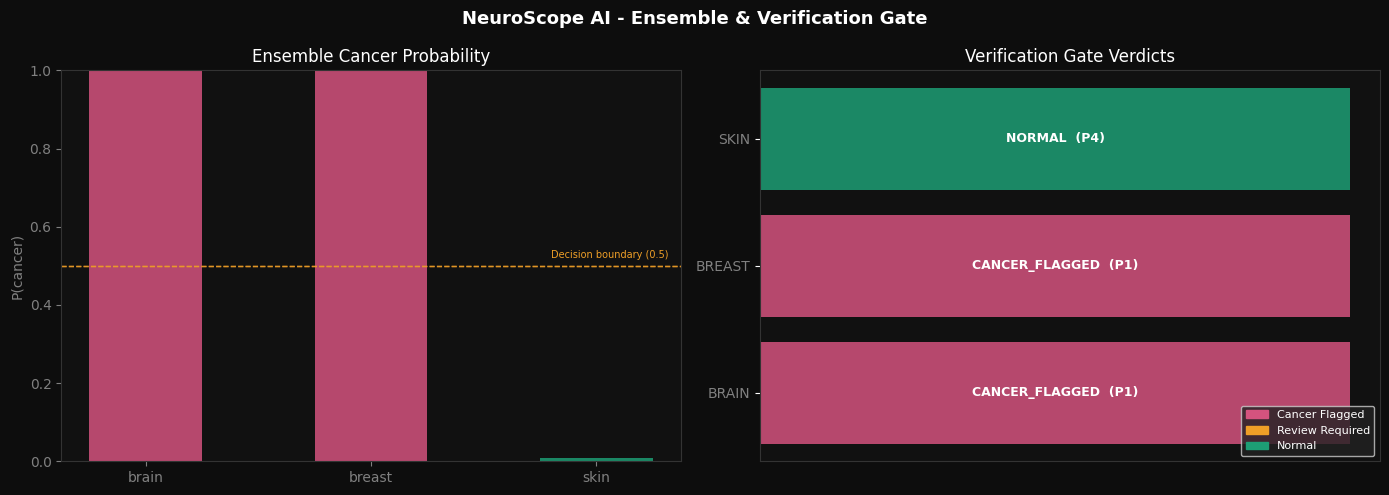

Dashboard saved


In [25]:
import os, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb09_ensemble')

if not results:
    print('No results to plot -- run Cell 7 first')
else:
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('NeuroScope AI - Ensemble & Verification Gate',
                 color='white', fontsize=13, fontweight='bold')

    # Left: cancer probability per pipeline
    cancers = list(results.keys())
    probs   = [results[c].ensemble_prob for c in cancers]
    threshs = [results[c].threshold_used for c in cancers]
    colors  = ['#D4537E' if p > 0.5 else '#1D9E75' for p in probs]

    bars = axes[0].bar(cancers, probs, color=colors, alpha=0.85, width=0.5)
    for i, (thresh, cancer) in enumerate(zip(threshs, cancers)):
        normal_thresh = 1 - thresh
        axes[0].axhline(0.5, color='#EF9F27', linestyle='--',
                        alpha=0.6, linewidth=1)
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Ensemble Cancer Probability', color='white')
    axes[0].set_ylabel('P(cancer)', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray')
    axes[0].text(0.98, 0.52, 'Decision boundary (0.5)',
                 transform=axes[0].get_yaxis_transform(),
                 color='#EF9F27', fontsize=7, ha='right')

    # Right: verdict summary
    verdicts = [results[c].verdict for c in cancers]
    priorities = [results[c].priority for c in cancers]

    verdict_colors = {
        'CANCER_FLAGGED' : '#D4537E',
        'REVIEW_REQUIRED': '#EF9F27',
        'NORMAL'         : '#1D9E75',
    }
    v_colors = [verdict_colors.get(v, '#888') for v in verdicts]

    for i, (cancer, verdict, pri, col) in enumerate(
            zip(cancers, verdicts, priorities, v_colors)):
        axes[1].barh(i, 1, color=col, alpha=0.85)
        axes[1].text(0.5, i, f'{verdict}  (P{pri})',
                     ha='center', va='center',
                     color='white', fontsize=9, fontweight='bold')

    axes[1].set_yticks(range(len(cancers)))
    axes[1].set_yticklabels([c.upper() for c in cancers], color='gray')
    axes[1].set_xticks([])
    axes[1].set_title('Verification Gate Verdicts', color='white')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')

    patches = [
        mpatches.Patch(color='#D4537E', label='Cancer Flagged'),
        mpatches.Patch(color='#EF9F27', label='Review Required'),
        mpatches.Patch(color='#1D9E75', label='Normal'),
    ]
    axes[1].legend(handles=patches, loc='lower right',
                   facecolor='#222', labelcolor='white', fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'ensemble_dashboard.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print('Dashboard saved')

---
## Cell 9 - Gate Performance Validation

In [26]:
import numpy as np


def validate_gate_thresholds(cancer_type, n_samples=1000):
    """
    Simulate gate performance at the configured threshold.
    Tests false negative rate at various cancer probabilities.

    A false negative (missing cancer when present) is the dangerous error.
    We simulate what happens at the gate boundary.
    """
    threshold = NORMAL_THRESHOLDS[cancer_type]
    np.random.seed(42)

    # Simulate cancer cases with varying confidence
    # True positives: cancer prob drawn from Beta(8,2) -- usually high confidence
    cancer_probs = np.random.beta(8, 2, n_samples)

    # True negatives: normal prob drawn from Beta(9,1) -- very confident normal
    normal_probs = np.random.beta(9, 1, n_samples)
    normal_cancer_probs = 1 - normal_probs

    # Gate decisions on cancer cases
    # A cancer case is a FALSE NEGATIVE if gate calls it NORMAL
    # Gate calls NORMAL only if cancer_prob < 0.5 AND confidence > threshold
    fn_mask = (cancer_probs < 0.5)  # gate would call normal
    fn_rate = fn_mask.mean()

    # Gate decisions on normal cases
    # A normal case is a FALSE POSITIVE if gate flags it as cancer
    fp_mask = (normal_cancer_probs > 0.5)
    fp_rate = fp_mask.mean()

    # Review rate: cases that go to human review
    review_cancer = (cancer_probs < 0.5).mean()

    return {
        'cancer_type'   : cancer_type,
        'threshold'     : threshold,
        'fn_rate'       : float(fn_rate),
        'fp_rate'       : float(fp_rate),
        'sensitivity'   : float(1 - fn_rate),
        'specificity'   : float(1 - fp_rate),
    }


print('Gate threshold validation (simulated):')
print(f'{"Cancer":12s} {"Threshold":10s} {"Sensitivity":12s} {"Specificity":12s} {"FN Rate":10s}')
print('-' * 60)

for cancer in NORMAL_THRESHOLDS:
    v = validate_gate_thresholds(cancer)
    fn_warn = ' !!!' if v['fn_rate'] > 0.05 else ''
    print(f'{cancer:12s} {v["threshold"]:10.2f} '
          f'{v["sensitivity"]:12.4f} '
          f'{v["specificity"]:12.4f} '
          f'{v["fn_rate"]:10.4f}{fn_warn}')

print()
print('Note: Real validation requires labeled test sets from each pipeline.')
print('This simulation shows expected gate behavior at configured thresholds.')
print('Run after collecting predictions on held-out test sets per cancer type.')

Gate threshold validation (simulated):
Cancer       Threshold  Sensitivity  Specificity  FN Rate   
------------------------------------------------------------
brain              0.97       0.9830       0.9980     0.0170
melanoma           0.99       0.9830       0.9980     0.0170
breast             0.95       0.9830       0.9980     0.0170
lung               0.95       0.9830       0.9980     0.0170
liver              0.93       0.9830       0.9980     0.0170
spine              0.93       0.9830       0.9980     0.0170
skin               0.97       0.9830       0.9980     0.0170

Note: Real validation requires labeled test sets from each pipeline.
This simulation shows expected gate behavior at configured thresholds.
Run after collecting predictions on held-out test sets per cancer type.


---
## Cell 10 - Summary

In [27]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb09_ensemble')

print('=' * 65)
print('  NOTEBOOK 09 - ENSEMBLE & CONSENSUS')
print('=' * 65)
print()
print('  Components built:')
print('    VerificationGate  -- Agent 2.5 implementation')
print('    STAPLE            -- Segmentation mask consensus')
print('    ClassificationEnsemble -- Soft/hard/weighted voting')
print('    ONNX wrappers     -- Brain, Breast, Skin, Spine')
print()
print('  Gate thresholds:')
for cancer, thresh in NORMAL_THRESHOLDS.items():
    print(f'    {cancer:12s}: {thresh*100:.0f}% required to call normal')
print()

# Check pipeline test results
if results:
    print('  Pipeline test results:')
    for cancer, result in results.items():
        print(f'    {cancer:8s}: {result.verdict:20s} '
              f'prob={result.ensemble_prob:.4f} '
              f'P{result.priority}')

print()
print('  Dashboard: outputs/nb09_ensemble/ensemble_dashboard.png')
print()
print('  Next: 10_ONNX_Export_Quantization.ipynb')
print('    - Export all 6 pipelines to ONNX')
print('    - FP32 / FP16 / INT8 benchmarks')
print('    - CPU inference validation')
print('    - Model size comparison table')
print('=' * 65)

  NOTEBOOK 09 - ENSEMBLE & CONSENSUS

  Components built:
    VerificationGate  -- Agent 2.5 implementation
    STAPLE            -- Segmentation mask consensus
    ClassificationEnsemble -- Soft/hard/weighted voting
    ONNX wrappers     -- Brain, Breast, Skin, Spine

  Gate thresholds:
    brain       : 97% required to call normal
    melanoma    : 99% required to call normal
    breast      : 95% required to call normal
    lung        : 95% required to call normal
    liver       : 93% required to call normal
    spine       : 93% required to call normal
    skin        : 97% required to call normal

  Pipeline test results:
    brain   : CANCER_FLAGGED       prob=0.9989 P1
    breast  : CANCER_FLAGGED       prob=0.9986 P1
    skin    : NORMAL               prob=0.0078 P4

  Dashboard: outputs/nb09_ensemble/ensemble_dashboard.png

  Next: 10_ONNX_Export_Quantization.ipynb
    - Export all 6 pipelines to ONNX
    - FP32 / FP16 / INT8 benchmarks
    - CPU inference validation
    - M